
# Part 1 Reliability Analysis of Accident Risk During Aircraft Landing

This notebook is a clean solution for **Part 1 only** of the airport project.

It is written to follow the **reliability-analysis methodology from the lecture slides**:

1. Define the **basic events** and their probabilities.
2. Build a **structure function** for each subsystem using **AND / OR logic**.
3. Use the lecture assumption of **independence**, except here we use the project's more specific assumption of **conditional independence given weather**.
4. Compute the subsystem risks for:
   - **wake vortex encounter**
   - **simultaneous runway occupancy**
5. Combine those two accident mechanisms into the **overall accident risk**.
6. Evaluate the **technology tradeoff levels**.
7. Explore how the answer changes as the percentage of **bad weather** increases.

---

## Interpretation used in this notebook

## <span style="color: red;">I wrote all the equations in this file in terms of AND and OR, you can rewrite them in terms of MIN and MAX for the report if you want!</span>

The project states that insufficient in-trail separation can create accident risk through **two main mechanisms**:

- wake vortex encounter
- simultaneous runway occupancy

So the overall accident event is modeled as:

$[
A = W \lor S
$]

where:

- \(W\) = wake-vortex accident event
- \(S\) = simultaneous-runway-occupancy accident event

This is exactly the sort of **system logic / structure-function** modeling emphasized in the lecture slides.

---

## Important note about climate change part

The project says that in 50 years the fraction of time with bad weather will increase, but it does **not** specify by how much.
So, instead of hard-coding one unsupported number, this notebook performs a **sensitivity analysis** over a range of bad-weather percentages.
That is usually the safest and most defensible way to answer that part unless your instructor gave a specific future percentage.


In [3]:

# ============================================================
# Imports
# ============================================================
# Only standard scientific Python tools are used.
# The notebook is intentionally kept simple and transparent.

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make tables easier to read in notebook output
#pd.set_option("display.float_format", lambda x: f"{x:.10e}")
#pd.set_option("display.float_format", lambda x: f"{x:.8f}")
pd.set_option("display.float_format", lambda x: f"{x:.2e}" if abs(x) < 1e-1 and x != 0 else f"{x:.2f}")



# 1. Enter the project data

We first store the values from the project statement.

The lecture slides emphasize that a reliability model starts by identifying the **basic components / events** and their probabilities.
Here, the "components" are the elementary events listed in the project tables.

We condition everything on weather:
- `good`
- `bad`

That matches the project statement, which says the events can be treated as **conditionally independent given the weather**.


In [4]:

# ============================================================
# Table 2: probability that the wake vortex is dangerous,
# given the sizes of the leading and trailing aircraft.
#
# The project's example says:
# heavy lead followed by small trail  -> probability 0.82
#
# That means the table should be interpreted as:
# rows    = trailing aircraft size
# columns = leading aircraft size
# ============================================================

size_mix = {
    "Heavy": 0.33,
    "Large": 0.46,
    "Small": 0.21,
}

dangerous_wake_table = pd.DataFrame(
    data=[
        [0.53, 0.44, 0.28],  # trailing Heavy, leading Heavy/Large/Small
        [0.74, 0.61, 0.41],  # trailing Large
        [0.82, 0.71, 0.59],  # trailing Small
    ],
    index=["Heavy", "Large", "Small"],    # trailing aircraft
    columns=["Heavy", "Large", "Small"],  # leading aircraft
)

dangerous_wake_table


,Heavy,Large,Small
Heavy,0.53,0.44,0.28
Large,0.74,0.61,0.41
Small,0.82,0.71,0.59


In [5]:

# ============================================================
# Tables 3 and 4 from the project
# ============================================================
# Each weather scenario gets its own dictionary of base-event
# probabilities.
#
# These are the primitive events used in the structure function.
# ============================================================

base_probs = {
    "good": {
        # Wake-vortex pathway inputs (Table 3)
        "misidentification": 2.69e-4,
        "misidentification_causes_violation": 3.82e-2,
        "misestimate_weather_effects": 5.19e-6,
        "atc_fails_to_communicate_on_time": 6.24e-5,
        "pilot_unable_to_adjust_speed": 7.23e-4,
        "pilot_unable_to_communicate_speed_problem": 1.17e-3,
        "lead_aircraft_goaround": 1.57e-4,
        "goaround_causes_violation": 2.01e-2,
        "atc_detection_system_fails": 1.95e-3,

        # Simultaneous-runway-occupancy pathway inputs (Table 4)
        "lead_cannot_leave_runway_equipment_failure": 5.12e-6,
        "lead_cannot_leave_runway_ground_congestion": 1.34e-4,
        "trailing_cannot_goaround_insufficient_reaction_time": 1.40e-3,
        "trailing_cannot_goaround_emergency": 8.36e-4,
    },
    "bad": {
        # Wake-vortex pathway inputs (Table 3)
        "misidentification": 2.69e-4,
        "misidentification_causes_violation": 3.82e-2,
        "misestimate_weather_effects": 2.33e-5,
        "atc_fails_to_communicate_on_time": 6.24e-5,
        "pilot_unable_to_adjust_speed": 4.34e-3,
        "pilot_unable_to_communicate_speed_problem": 1.17e-3,
        "lead_aircraft_goaround": 4.71e-4,
        "goaround_causes_violation": 2.01e-2,
        "atc_detection_system_fails": 1.95e-3,

        # Simultaneous-runway-occupancy pathway inputs (Table 4)
        "lead_cannot_leave_runway_equipment_failure": 5.12e-6,
        "lead_cannot_leave_runway_ground_congestion": 3.22e-4,
        "trailing_cannot_goaround_insufficient_reaction_time": 8.70e-3,
        "trailing_cannot_goaround_emergency": 8.36e-4,
    }
}

# Table 5 tradeoff values:
# (decrease in P[pilot unable to adjust speed],
#  increase in P[trailing aircraft cannot initiate go-around due to insufficient reaction time])
tradeoff_table = {
    1:  (0.00e-4,  0.0e-6),
    2:  (3.63e-4,  1.0e-6),
    3:  (4.68e-4,  2.0e-6),
    4:  (4.88e-4,  3.0e-6),
    5:  (4.94e-4,  4.0e-6),
    6:  (4.96e-4,  5.0e-6),
    7:  (5.03e-4,  6.0e-6),
    8:  (5.08e-4,  7.0e-6),
    9:  (5.11e-4,  8.0e-6),
    10: (5.14e-4,  9.0e-6),
    11: (5.17e-4, 10.0e-6),
}

pd.DataFrame(tradeoff_table, index=["speed_adjustment_decrease", "goaround_reaction_increase"]).T


,speed_adjustment_decrease,goaround_reaction_increase
1,0.00,0.00
2,3.63e-04,1.00e-06
3,4.68e-04,2.00e-06
4,4.88e-04,3.00e-06
5,4.94e-04,4.00e-06
6,4.96e-04,5.00e-06
7,5.03e-04,6.00e-06
8,5.08e-04,7.00e-06
9,5.11e-04,8.00e-06
10,5.14e-04,9.00e-06



# 2. Compute the probability of a dangerous wake vortex

The project gives:
- the aircraft size mix
- the probability that a wake vortex is dangerous for each lead/trail size pair

So the probability of a dangerous wake vortex is the weighted average over all lead/trail combinations:

$[
P(D) = \sum_{\text{trail}} \sum_{\text{lead}}
P(\text{trail size}) P(\text{lead size}) P(D \mid \text{trail, lead})
$]

This is a straightforward expectation calculation.


In [6]:
# ============================================================
# Compute per-pair wake-vortex probabilities
# ============================================================
# We keep the dangerous wake probabilities by aircraft pair so the
# reliability analysis can be performed case by case (no averaging).
# ============================================================

pair_occurrence = pd.DataFrame(
    0.0,
    index=dangerous_wake_table.index,
    columns=dangerous_wake_table.columns,
    dtype=float,
 )

for trailing_size, p_trailing in size_mix.items():
    for leading_size, p_leading in size_mix.items():
        pair_occurrence.loc[trailing_size, leading_size] = p_trailing * p_leading

dangerous_wake_probability = dangerous_wake_table.copy()
pair_occurence_probabilities = pd.DataFrame(pair_occurrence)
pair_occurence_risk = dangerous_wake_table * pair_occurrence

#dangerous_wake_probability
#pair_occurence_probabilities
pair_occurence_risk

,Heavy,Large,Small
Heavy,5.77e-02,6.68e-02,1.94e-02
Large,0.11,0.13,3.96e-02
Small,5.68e-02,6.86e-02,2.60e-02



# 3. Reliability building blocks

The lecture slides emphasize working with a **structure function**.

For independent events:
- AND of events becomes a **product**
- OR of events becomes **one minus the product of complements**

So we define a helper for OR:

$[
P(E_1 \cup E_2 \cup \cdots \cup E_n) = 1 - \prod_{i=1}^{n} (1 - P(E_i))
$]

We will use that repeatedly below.


In [7]:

# ============================================================
# Helper functions for reliability calculations
# ============================================================

def prob_or(*probabilities):
    """Probability that at least one independent event occurs."""
    product_of_complements = 1.0
    for p in probabilities:
        product_of_complements *= (1.0 - p)
    return 1.0 - product_of_complements


def probability_weighted_by_weather(prob_good, prob_bad, p_bad):
    """Combine conditional probabilities using the law of total probability."""
    p_good = 1.0 - p_bad
    return p_good * prob_good + p_bad * prob_bad



# 4. Build the structure functions

## 4.1 Wake-vortex encounter logic

From the project statement, an in-trail separation violation can happen through three branches:

1. **Air traffic control branch**
2. **Trailing aircraft branch**
3. **Leading aircraft go-around branch**

### Air traffic control branch
A violation happens if **any** of these occurs:
- aircraft misidentification **and** that misidentification causes a violation
- misestimate of weather effects
- failure to communicate on time

So:

$[
A_{\text{ATC}} = (M \land MV) \lor W \lor C 
$]

### Trailing aircraft branch
A violation occurs if:
- pilot cannot adjust speed
- and the pilot also cannot communicate that problem back promptly

$[
A_{\text{trail}} = S \land U
$]

### Leading aircraft branch
A violation occurs if:
- the lead aircraft must go around
- and that go-around causes a separation violation

$[
A_{\text{lead}} = G \land GV
$]

### Any separation violation
$[
V = A_{\text{ATC}} \lor A_{\text{trail}} \lor A_{\text{lead}}
$]

### Wake-vortex accident event
For a wake-vortex accident, we need:
- a dangerous wake vortex exists
- a separation violation occurs
- the ATC detection/correction system fails

$[
W = D \land V \land F
$]

---

## 4.2 Simultaneous runway occupancy logic

For simultaneous runway occupancy:

### Lead aircraft branch
The lead aircraft fails to vacate the runway if:
- equipment failure
- or ground congestion

$[
L = E \lor G
$]

### Trailing aircraft branch
The trailing aircraft cannot avoid the runway occupancy if it cannot go around because of:
- insufficient reaction time
- or emergency

$[
T = R \lor EM
$]

### Simultaneous runway occupancy event
$[
S = L \land T
$]

---

## 4.3 Overall accident logic

The project says insufficient in-trail separation creates accident risk due to two main reasons:
- wake vortex encounter
- simultaneous runway occupancy

So the overall accident event is:

$[
A = W \lor S
$]

That is the final top-level structure function.


In [8]:
# ============================================================
# Core reliability model
# ============================================================
# This function computes the full accident-risk breakdown for one
# weather scenario and one technology tradeoff level.
#
# The wake-vortex branch is kept case-by-case by lead/trail pair.
# ============================================================

def compute_risk_given_weather(weather, tradeoff_level=1):
    """
    Compute all intermediate and final probabilities for one weather condition.

    Parameters
    ----------
    weather : str
        Either "good" or "bad".
    tradeoff_level : int
        Integer from 1 to 11.

    Returns
    -------
    dict
        Dictionary containing intermediate branch probabilities
        and final risk measures, including pair-level risk tables.
    """
    p = dict(base_probs[weather])

    # Apply the technology tradeoff
    decrease_speed_failure, increase_reaction_failure = tradeoff_table[tradeoff_level]
    p["pilot_unable_to_adjust_speed"] -= decrease_speed_failure
    p["trailing_cannot_goaround_insufficient_reaction_time"] += increase_reaction_failure

    # -----------------------------
    # WAKE-VORTEX SUBSYSTEM
    # -----------------------------
    atc_branch = prob_or(
        p["misidentification"] * p["misidentification_causes_violation"],
        p["misestimate_weather_effects"],
        p["atc_fails_to_communicate_on_time"],
    )

    trailing_branch = (
        p["pilot_unable_to_adjust_speed"]
        * p["pilot_unable_to_communicate_speed_problem"]
    )

    leading_branch = (
        p["lead_aircraft_goaround"]
        * p["goaround_causes_violation"]
    )

    separation_violation = prob_or(
        atc_branch,
        trailing_branch,
        leading_branch,
    )

    pair_risk_scale = separation_violation * p["atc_detection_system_fails"]
    wake_vortex_risk_by_pair = pair_occurence_risk * pair_risk_scale

    # -----------------------------
    # SIMULTANEOUS RUNWAY OCCUPANCY SUBSYSTEM
    # -----------------------------
    lead_fails_to_vacate = prob_or(
        p["lead_cannot_leave_runway_equipment_failure"],
        p["lead_cannot_leave_runway_ground_congestion"],
    )

    trailing_cannot_goaround = prob_or(
        p["trailing_cannot_goaround_insufficient_reaction_time"],
        p["trailing_cannot_goaround_emergency"],
    )

    simultaneous_runway_occupancy_risk = (
        lead_fails_to_vacate * trailing_cannot_goaround * pair_occurrence
    )

    # Keep overall accident risk by pair (no summation over pairs).
    overall_accident_risk_by_pair = prob_or(
        wake_vortex_risk_by_pair,
        simultaneous_runway_occupancy_risk,
    )

    return {
        "weather": weather,
        "tradeoff_level": tradeoff_level,
        "pair_occurrence": pair_occurrence,
        "dangerous_wake_probability_by_pair": dangerous_wake_probability,
        "atc_branch": atc_branch,
        "trailing_branch": trailing_branch,
        "leading_branch": leading_branch,
        "separation_violation": separation_violation,
        "wake_vortex_risk_by_pair": wake_vortex_risk_by_pair,
        "lead_fails_to_vacate": lead_fails_to_vacate,
        "trailing_cannot_goaround": trailing_cannot_goaround,
        "simultaneous_runway_occupancy_risk": simultaneous_runway_occupancy_risk,
        "overall_accident_risk_by_pair": overall_accident_risk_by_pair,
    }


# 5. Baseline results for good weather versus bad weather

This directly answers the first project objective:
> Calculate and compare the overall accident risk when the weather is good versus when the weather is bad.

We start with **tradeoff level 1**, which is the no-relaxation / no-extra-tradeoff baseline from Table 5.


In [9]:
# ============================================================
# Baseline good-weather and bad-weather results (case by case)
# ============================================================

baseline_good = compute_risk_given_weather("good", tradeoff_level=1)
baseline_bad = compute_risk_given_weather("bad", tradeoff_level=1)

def _pair_table_from_result(result):
    weather = result["weather"]
    wake = result["wake_vortex_risk_by_pair"].stack().rename("wake_vortex_risk_by_pair")
    sro = result["simultaneous_runway_occupancy_risk"].stack().rename("simultaneous_runway_occupancy_risk")
    overall = result["overall_accident_risk_by_pair"].stack().rename("overall_accident_risk_by_pair")

    df = pd.concat([wake, sro, overall], axis=1).reset_index()
    df = df.rename(columns={"level_0": "trailing_size", "level_1": "leading_size"})
    df["weather"] = weather
    return df[[
        "weather",
        "trailing_size",
        "leading_size",
        "wake_vortex_risk_by_pair",
        "simultaneous_runway_occupancy_risk",
        "overall_accident_risk_by_pair",
    ]]

baseline_pair_df = pd.concat([
    _pair_table_from_result(baseline_good),
    _pair_table_from_result(baseline_bad),
], ignore_index=True)

baseline_pair_df

,weather,trailing_size,leading_size,wake_vortex_risk_by_pair,simultaneous_runway_occupancy_risk,overall_accident_risk_by_pair
0,good,Heavy,Heavy,9.21e-09,3.39e-08,4.31e-08
1,good,Heavy,Large,1.07e-08,4.72e-08,5.79e-08
2,good,Heavy,Small,3.10e-09,2.15e-08,2.46e-08
3,good,Large,Heavy,1.79e-08,4.72e-08,6.51e-08
4,good,Large,Large,2.06e-08,6.58e-08,8.64e-08
5,good,Large,Small,6.32e-09,3.00e-08,3.64e-08
6,good,Small,Heavy,9.07e-09,2.15e-08,3.06e-08
7,good,Small,Large,1.09e-08,3.00e-08,4.10e-08
8,good,Small,Small,4.15e-09,1.37e-08,1.79e-08
9,bad,Heavy,Heavy,1.24e-08,3.39e-07,3.52e-07


In [10]:
# Pair-by-pair baseline summary table for the report
summary_good_bad = baseline_pair_df.pivot_table(
    index=["trailing_size", "leading_size"],
    columns="weather",
    values=[
        "wake_vortex_risk_by_pair",
        "simultaneous_runway_occupancy_risk",
        "overall_accident_risk_by_pair",
    ],
)

summary_good_bad

overall_accident_risk_by_pair           \
weather                                              bad     good   
trailing_size leading_size                                          
Heavy         Heavy                             3.52e-07 4.31e-08   
              Large                             4.88e-07 5.79e-08   
              Small                             2.20e-07 2.46e-08   
Large         Heavy                             4.97e-07 6.51e-08   
              Large                             6.87e-07 8.64e-08   
              Small                             3.10e-07 3.64e-08   
Small         Heavy                             2.28e-07 3.06e-08   
              Large                             3.16e-07 4.10e-08   
              Small                             1.43e-07 1.79e-08   

                           simultaneous_runway_occupancy_risk           \
weather                                                   bad     good   
trailing_size leading_size                                               
Heavy         Heavy                                  3.39e-07 3.39e-08   
              Large                                  4.73e-07 4.72e-08   
              Small                                  2.16e-07 2.15e-08   
Large         Heavy                                  4.73e-07 4.72e-08   
              Large                                  6.60e-07 6.58e-08   
              Small                                  3.01e-07 3.00e-08   
Small         Heavy                                  2.16e-07 2.15e-08   
              Large                                  3.01e-07 3.00e-08   
              Small                                  1.37e-07 1.37e-08   

                           wake_vortex_risk_by_pair           
weather                                         bad     good  
trailing_size leading_size                                    
Heavy         Heavy                        1.24e-08 9.21e-09  
              Large                        1.44e-08 1.07e-08  
              Small                        4.18e-09 3.10e-09  
Large         Heavy                        2.42e-08 1.79e-08  
              Large                        2.78e-08 2.06e-08  
              Small                        8.54e-09 6.32e-09  
Small         Heavy                        1.22e-08 9.07e-09  
              Large                        1.48e-08 1.09e-08  
              Small                        5.61e-09 4.15e-09


# 6. Evaluate the new technology under the 80% good / 20% bad weather mix

Now we answer the second project objective.

The project says:
- weather is good 80% of the time
- weather is bad 20% of the time

So for each tradeoff level, the unconditional accident risk is:

$[
P(A) = 0.8 \, P(A \mid \text{good}) + 0.2 \, P(A \mid \text{bad})
$]

We calculate this for all 11 levels and then choose the level with the **minimum overall accident risk**.


In [11]:
# ============================================================
# Evaluate all tradeoff levels under the 80/20 weather mix
# Case-by-case (lead/trail) reliability results
# ============================================================

def compute_mixed_weather_results(p_bad=0.20):
    """
    Compute pair-level accident risk for each tradeoff level under a specified
    bad-weather fraction.
    """
    rows = []

    for level in sorted(tradeoff_table.keys()):
        good = compute_risk_given_weather("good", tradeoff_level=level)
        bad = compute_risk_given_weather("bad", tradeoff_level=level)

        mixed_wake_by_pair = probability_weighted_by_weather(
            good["wake_vortex_risk_by_pair"],
            bad["wake_vortex_risk_by_pair"],
            p_bad,
        )

        mixed_sro_by_pair = probability_weighted_by_weather(
            good["simultaneous_runway_occupancy_risk"],
            bad["simultaneous_runway_occupancy_risk"],
            p_bad,
        )

        mixed_total_by_pair = probability_weighted_by_weather(
            good["overall_accident_risk_by_pair"],
            bad["overall_accident_risk_by_pair"],
            p_bad,
        )

        for trailing_size in mixed_total_by_pair.index:
            for leading_size in mixed_total_by_pair.columns:
                rows.append({
                    "tradeoff_level": level,
                    "bad_weather_fraction": p_bad,
                    "good_weather_fraction": 1.0 - p_bad,
                    "trailing_size": trailing_size,
                    "leading_size": leading_size,
                    "wake_vortex_risk_mixed": mixed_wake_by_pair.loc[trailing_size, leading_size],
                    "sro_risk_mixed": mixed_sro_by_pair.loc[trailing_size, leading_size],
                    "overall_accident_risk_mixed": mixed_total_by_pair.loc[trailing_size, leading_size],
                    "good_weather_total_risk": good["overall_accident_risk_by_pair"].loc[trailing_size, leading_size],
                    "bad_weather_total_risk": bad["overall_accident_risk_by_pair"].loc[trailing_size, leading_size],
                })

    return pd.DataFrame(rows)


results_80_20 = compute_mixed_weather_results(p_bad=0.20)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(results_80_20)
#results_80_20

,tradeoff_level,bad_weather_fraction,good_weather_fraction,trailing_size,leading_size,wake_vortex_risk_mixed,sro_risk_mixed,overall_accident_risk_mixed,good_weather_total_risk,bad_weather_total_risk
0,1,0.20,0.80,Heavy,Heavy,9.86e-09,9.50e-08,1.05e-07,4.31e-08,3.52e-07
1,1,0.20,0.80,Heavy,Large,1.14e-08,1.32e-07,1.44e-07,5.79e-08,4.88e-07
2,1,0.20,0.80,Heavy,Small,3.31e-09,6.04e-08,6.38e-08,2.46e-08,2.20e-07
3,1,0.20,0.80,Large,Heavy,1.92e-08,1.32e-07,1.52e-07,6.51e-08,4.97e-07
4,1,0.20,0.80,Large,Large,2.20e-08,1.85e-07,2.07e-07,8.64e-08,6.87e-07
5,1,0.20,0.80,Large,Small,6.77e-09,8.42e-08,9.10e-08,3.64e-08,3.10e-07
6,1,0.20,0.80,Small,Heavy,9.71e-09,6.04e-08,7.01e-08,3.06e-08,2.28e-07
7,1,0.20,0.80,Small,Large,1.17e-08,8.42e-08,9.60e-08,4.10e-08,3.16e-07
8,1,0.20,0.80,Small,Small,4.44e-09,3.85e-08,4.29e-08,1.79e-08,1.43e-07
9,2,0.20,0.80,Heavy,Heavy,9.81e-09,9.50e-08,1.05e-07,4.30e-08,3.52e-07


In [12]:
# Identify the optimal tradeoff level for each aircraft-pair case
best_rows_80_20 = results_80_20.loc[
    results_80_20.groupby(["trailing_size", "leading_size"])["overall_accident_risk_mixed"].idxmin()
]

best_rows_80_20 = best_rows_80_20.sort_values(["trailing_size", "leading_size"]).reset_index(drop=True)
best_rows_80_20

,tradeoff_level,bad_weather_fraction,good_weather_fraction,trailing_size,leading_size,wake_vortex_risk_mixed,sro_risk_mixed,overall_accident_risk_mixed,good_weather_total_risk,bad_weather_total_risk
0,2,0.20,0.80,Heavy,Heavy,9.81e-09,9.50e-08,1.05e-07,4.30e-08,3.52e-07
1,2,0.20,0.80,Heavy,Large,1.14e-08,1.32e-07,1.44e-07,5.78e-08,4.88e-07
2,2,0.20,0.80,Heavy,Small,3.30e-09,6.05e-08,6.37e-08,2.46e-08,2.20e-07
3,3,0.20,0.80,Large,Heavy,1.91e-08,1.32e-07,1.52e-07,6.51e-08,4.97e-07
4,2,0.20,0.80,Large,Large,2.19e-08,1.85e-07,2.07e-07,8.63e-08,6.87e-07
5,2,0.20,0.80,Large,Small,6.73e-09,8.43e-08,9.10e-08,3.63e-08,3.10e-07
6,3,0.20,0.80,Small,Heavy,9.65e-09,6.05e-08,7.01e-08,3.06e-08,2.28e-07
7,2,0.20,0.80,Small,Large,1.17e-08,8.43e-08,9.59e-08,4.09e-08,3.16e-07
8,2,0.20,0.80,Small,Small,4.42e-09,3.85e-08,4.29e-08,1.78e-08,1.43e-07


In [13]:
# A compact ranking table (best to worst) within each aircraft pair
ranking_80_20 = results_80_20.sort_values(
    ["trailing_size", "leading_size", "overall_accident_risk_mixed"]
).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(ranking_80_20)
#ranking_80_20

,tradeoff_level,bad_weather_fraction,good_weather_fraction,trailing_size,leading_size,wake_vortex_risk_mixed,sro_risk_mixed,overall_accident_risk_mixed,good_weather_total_risk,bad_weather_total_risk
0,2,0.20,0.80,Heavy,Heavy,9.81e-09,9.50e-08,1.05e-07,4.30e-08,3.52e-07
1,3,0.20,0.80,Heavy,Heavy,9.80e-09,9.50e-08,1.05e-07,4.30e-08,3.52e-07
2,4,0.20,0.80,Heavy,Heavy,9.79e-09,9.50e-08,1.05e-07,4.31e-08,3.52e-07
3,1,0.20,0.80,Heavy,Heavy,9.86e-09,9.50e-08,1.05e-07,4.31e-08,3.52e-07
4,5,0.20,0.80,Heavy,Heavy,9.79e-09,9.51e-08,1.05e-07,4.31e-08,3.52e-07
5,6,0.20,0.80,Heavy,Heavy,9.79e-09,9.51e-08,1.05e-07,4.31e-08,3.52e-07
6,7,0.20,0.80,Heavy,Heavy,9.79e-09,9.51e-08,1.05e-07,4.31e-08,3.52e-07
7,8,0.20,0.80,Heavy,Heavy,9.79e-09,9.51e-08,1.05e-07,4.31e-08,3.52e-07
8,9,0.20,0.80,Heavy,Heavy,9.79e-09,9.51e-08,1.05e-07,4.31e-08,3.52e-07
9,10,0.20,0.80,Heavy,Heavy,9.79e-09,9.51e-08,1.05e-07,4.31e-08,3.52e-07


In [14]:
# ============================================================
# New experiment: aircraft-type-specific tradeoff levels (80/20 mix)
# ============================================================
# For each scenario (Heavy level, Large level, Small level), compute pair-specific
# risk, then identify the best tradeoff per aircraft type based on risks where
# that type appears as trailing OR leading.

# Example scenarios included in this exhaustive search:
# (1,1,1), (2,1,1), ..., (11,11,11) and all combinations in between.

from itertools import product

type_names = ["Heavy", "Large", "Small"]
levels = list(range(1, 12))
p_bad = 0.20

# Cache results to avoid recomputing the same (weather, level) model outputs
risk_cache = {}
for weather in ["good", "bad"]:
    for level in levels:
        risk_cache[(weather, level)] = compute_risk_given_weather(weather, tradeoff_level=level)

scenario_pair_rows = []

for heavy_level, large_level, small_level in product(levels, levels, levels):
    scenario_levels = {
        "Heavy": heavy_level,
        "Large": large_level,
        "Small": small_level,
    }

    for trailing in type_names:
        lvl = scenario_levels[trailing]
        good_matrix = risk_cache[("good", lvl)]["overall_accident_risk_by_pair"]
        bad_matrix = risk_cache[("bad", lvl)]["overall_accident_risk_by_pair"]

        for leading in type_names:
            mixed_risk = (1.0 - p_bad) * good_matrix.loc[trailing, leading] + p_bad * bad_matrix.loc[trailing, leading]
            scenario_pair_rows.append({
                "heavy_level": heavy_level,
                "large_level": large_level,
                "small_level": small_level,
                "trailing_size": trailing,
                "leading_size": leading,
                "overall_accident_risk_mixed": mixed_risk,
            })

scenario_pair_df = pd.DataFrame(scenario_pair_rows)

# A compact scenario-level summary (mean of the 9 pair risks per scenario)
scenario_summary_df = (scenario_pair_df.groupby(["heavy_level", "large_level", "small_level"], as_index=False)["overall_accident_risk_mixed"].mean().rename(columns={"overall_accident_risk_mixed": "mean_pair_risk"}))

# For each scenario and each aircraft type, average risk over pairs where the type
# appears either as trailing or as leading.
type_exposure_rows = []
for (h, l, s), grp in scenario_pair_df.groupby(["heavy_level", "large_level", "small_level"]):
    level_map = {"Heavy": h, "Large": l, "Small": s}
    for aircraft_type in type_names:
        involved = grp[(grp["trailing_size"] == aircraft_type) | (grp["leading_size"] == aircraft_type)]
        type_exposure_rows.append({
            "aircraft_type": aircraft_type,
            "chosen_level_for_type": level_map[aircraft_type],
            "heavy_level": h,
            "large_level": l,
            "small_level": s,
            "mean_involved_pair_risk": involved["overall_accident_risk_mixed"].mean(),
        })

type_exposure_df = pd.DataFrame(type_exposure_rows)

# Marginalize over all other-type settings to pick a best level for each type.
type_level_score = (
    type_exposure_df
    .groupby(["aircraft_type", "chosen_level_for_type"], as_index=False)["mean_involved_pair_risk"]
    .mean()
    .sort_values(["aircraft_type", "mean_involved_pair_risk"])
    .rename(columns={"chosen_level_for_type": "tradeoff_level"})
)

optimal_tradeoff_by_type = (
    type_level_score
    .loc[type_level_score.groupby("aircraft_type")["mean_involved_pair_risk"].idxmin()]
    .sort_values("aircraft_type")
    .reset_index(drop=True)
    .rename(columns={"mean_involved_pair_risk": "average_risk_when_type_is_involved"})
)

# Display key outputs
print("Number of scenarios evaluated:", len(scenario_summary_df))
print("Number of pair rows (scenarios x 9 pairs):", len(scenario_pair_df))

print("\nTop 10 scenario-level combinations by mean pair risk:")
display(scenario_summary_df.nsmallest(10, "mean_pair_risk"))

print("\nOptimal tradeoff per aircraft type (based on trailing+leading involvement):")
display(optimal_tradeoff_by_type)

print("\nFull per-type level score table:")
display(type_level_score)

Number of scenarios evaluated: 1331
Number of pair rows (scenarios x 9 pairs): 11979

Top 10 scenario-level combinations by mean pair risk:


,heavy_level,large_level,small_level,mean_pair_risk
133,2,2,2,1.08e-07
134,2,2,3,1.08e-07
144,2,3,2,1.08e-07
145,2,3,3,1.08e-07
254,3,2,2,1.08e-07
255,3,2,3,1.08e-07
135,2,2,4,1.08e-07
265,3,3,2,1.08e-07
266,3,3,3,1.08e-07
146,2,3,4,1.08e-07



Optimal tradeoff per aircraft type (based on trailing+leading involvement):


,aircraft_type,tradeoff_level,average_risk_when_type_is_involved
0,Heavy,2,1.07e-07
1,Large,2,1.38e-07
2,Small,2,7.28e-08



Full per-type level score table:


,aircraft_type,tradeoff_level,mean_involved_pair_risk
1,Heavy,2,1.07e-07
2,Heavy,3,1.07e-07
0,Heavy,1,1.07e-07
3,Heavy,4,1.07e-07
4,Heavy,5,1.07e-07
5,Heavy,6,1.07e-07
6,Heavy,7,1.07e-07
7,Heavy,8,1.07e-07
8,Heavy,9,1.07e-07
9,Heavy,10,1.07e-07


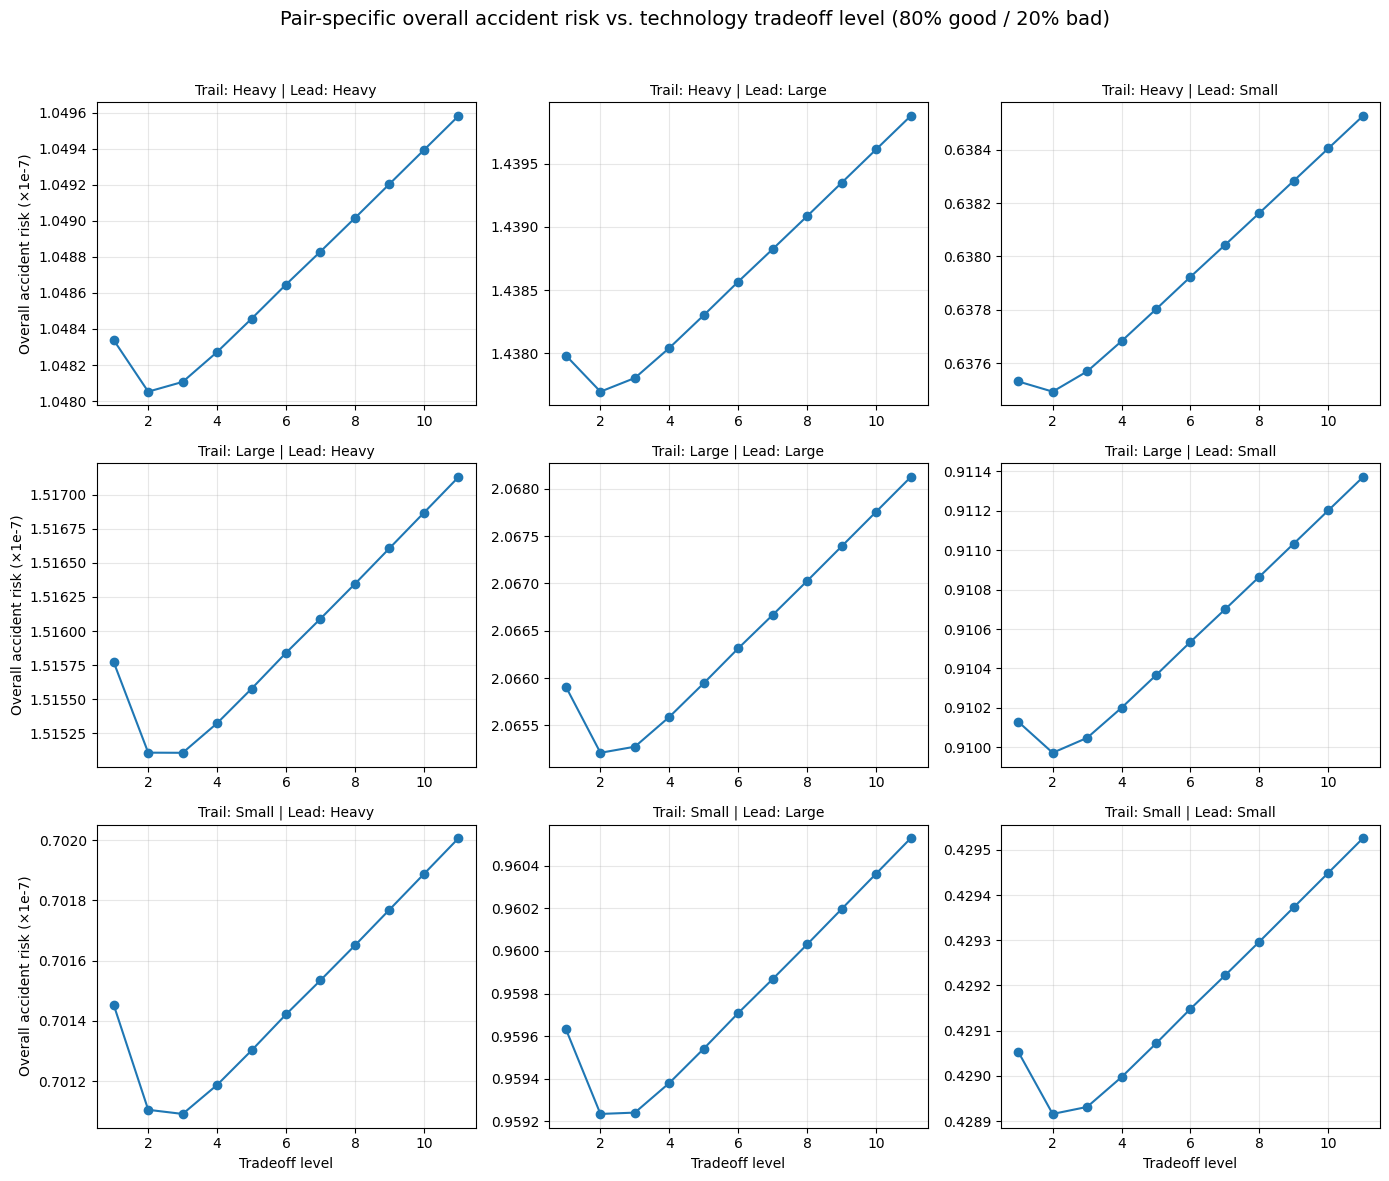

In [15]:
# Plot pair-specific risk versus tradeoff level under the 80/20 mix (3x3 grid)
trailing_order = ["Heavy", "Large", "Small"]
leading_order = ["Heavy", "Large", "Small"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)

for i, trailing_size in enumerate(trailing_order):
    for j, leading_size in enumerate(leading_order):
        ax = axes[i, j]
        subset = results_80_20[
            (results_80_20["trailing_size"] == trailing_size)
            & (results_80_20["leading_size"] == leading_size)
        ].sort_values("tradeoff_level")

        ax.plot(
            subset["tradeoff_level"],
            subset["overall_accident_risk_mixed"] * 1e7,
            marker="o",
        )
        ax.set_title(f"Trail: {trailing_size} | Lead: {leading_size}", fontsize=10)
        ax.grid(True, alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Tradeoff level")

for ax in axes[:, 0]:
    ax.set_ylabel("Overall accident risk (×1e-7)")

fig.suptitle(
    "Pair-specific overall accident risk vs. technology tradeoff level (80% good / 20% bad)",
    fontsize=14,
    y=0.98,
 )
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

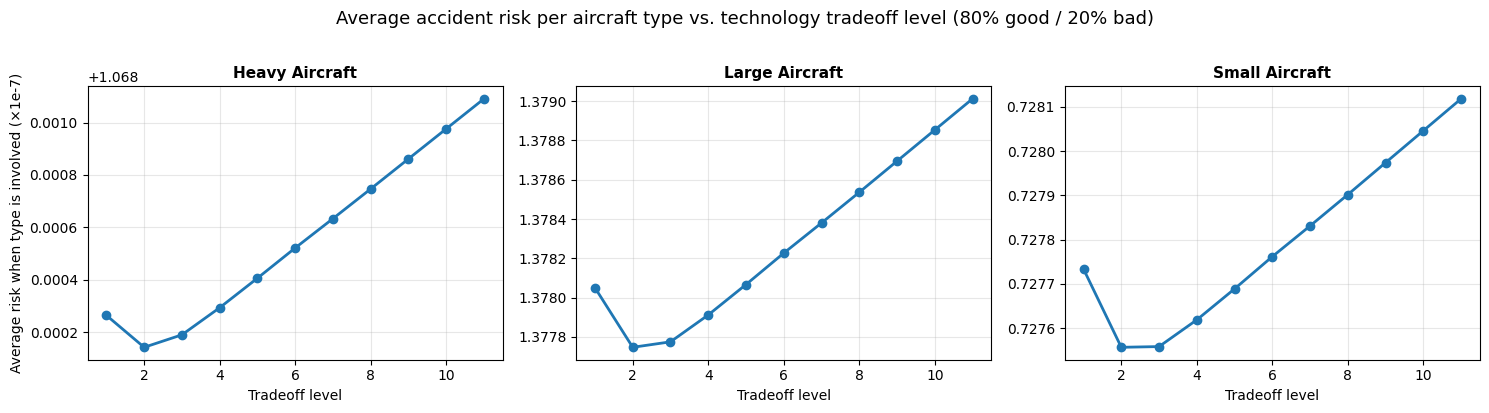

In [16]:
# Plot average risk per aircraft type versus tradeoff level (1x3 grid)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

for idx, aircraft_type in enumerate(type_names):
    ax = axes[idx]
    subset = type_level_score[type_level_score["aircraft_type"] == aircraft_type].sort_values("tradeoff_level")
    
    ax.plot(
        subset["tradeoff_level"],
        subset["mean_involved_pair_risk"] * 1e7,
        marker="o",
        linewidth=2,
        markersize=6,
    )
    ax.set_title(f"{aircraft_type} Aircraft", fontsize=11, fontweight="bold")
    ax.set_xlabel("Tradeoff level")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Average risk when type is involved (×1e-7)")

fig.suptitle(
    "Average accident risk per aircraft type vs. technology tradeoff level (80% good / 20% bad)",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()



# 7. Climate-change sensitivity analysis

The project says that in 50 years the percentage of time with bad weather is expected to increase.

Because no single future percentage is provided, we examine a whole range of values for the bad-weather fraction:
- 20%
- 25%
- 30%
- ...
- 100%

This allows us to answer:
- how the overall risk changes as bad weather becomes more common
- whether the **optimal tradeoff level** changes


In [17]:
# ============================================================
# Sensitivity analysis over the bad-weather fraction (case by case)
# ============================================================

sensitivity_rows = []

for p_bad in np.linspace(0.2, 1.0, 17):  # 20%, 25%, ..., 100%
    mixed_results = compute_mixed_weather_results(p_bad=p_bad)
    best_rows = mixed_results.loc[
        mixed_results.groupby(["trailing_size", "leading_size"])["overall_accident_risk_mixed"].idxmin()
    ]

    for _, row in best_rows.iterrows():
        sensitivity_rows.append({
            "bad_weather_fraction": p_bad,
            "good_weather_fraction": 1.0 - p_bad,
            "trailing_size": row["trailing_size"],
            "leading_size": row["leading_size"],
            "optimal_tradeoff_level": int(row["tradeoff_level"]),
            "minimum_overall_accident_risk": row["overall_accident_risk_mixed"],
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
# Option 1: temporary full display
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(sensitivity_df)
#sensitivity_df

,bad_weather_fraction,good_weather_fraction,trailing_size,leading_size,optimal_tradeoff_level,minimum_overall_accident_risk
0,0.20,0.80,Heavy,Heavy,2,1.05e-07
1,0.20,0.80,Heavy,Large,2,1.44e-07
2,0.20,0.80,Heavy,Small,2,6.37e-08
3,0.20,0.80,Large,Heavy,3,1.52e-07
4,0.20,0.80,Large,Large,2,2.07e-07
5,0.20,0.80,Large,Small,2,9.10e-08
6,0.20,0.80,Small,Heavy,3,7.01e-08
7,0.20,0.80,Small,Large,2,9.59e-08
8,0.20,0.80,Small,Small,2,4.29e-08
9,0.25,0.75,Heavy,Heavy,2,1.20e-07


In [18]:
# Summary table: for each aircraft pair, aggregate across all weather fractions
pair_summary_rows = []

for (trailing_size, leading_size), group in sensitivity_df.groupby(["trailing_size", "leading_size"]):
    mean_min_risk = group["minimum_overall_accident_risk"].mean()
    # Get the most common tradeoff level across all weather fractions
    mode_level = group["optimal_tradeoff_level"].mode()
    if len(mode_level) > 0:
        most_common_level = mode_level.iloc[0]
    else:
        most_common_level = group["optimal_tradeoff_level"].iloc[0]
    
    pair_summary_rows.append({
        "trailing_size": trailing_size,
        "leading_size": leading_size,
        "mean_minimum_accident_risk": mean_min_risk,
        "most_common_tradeoff_level": most_common_level,
    })

pair_summary_df = pd.DataFrame(pair_summary_rows).sort_values(["trailing_size", "leading_size"]).reset_index(drop=True)
pair_summary_df

,trailing_size,leading_size,mean_minimum_accident_risk,most_common_tradeoff_level
0,Heavy,Heavy,2.28e-07,2
1,Heavy,Large,3.16e-07,2
2,Heavy,Small,1.42e-07,1
3,Large,Heavy,3.24e-07,2
4,Large,Large,4.47e-07,2
5,Large,Small,2.00e-07,2
6,Small,Heavy,1.49e-07,2
7,Small,Large,2.06e-07,2
8,Small,Small,9.30e-08,2


In [19]:
# Aircraft-level summary: aggregate by aircraft type across all pairs where it's involved
aircraft_summary_rows = []

for aircraft_type in type_names:
    # Get all pairs where this aircraft appears (either trailing or leading)
    involved_pairs = pair_summary_df[
        (pair_summary_df["trailing_size"] == aircraft_type) | 
        (pair_summary_df["leading_size"] == aircraft_type)
    ]
    
    # Calculate average minimum accident risk across these pairs
    avg_min_risk = involved_pairs["mean_minimum_accident_risk"].mean()
    
    # Get the most common tradeoff level for pairs where this aircraft is involved
    mode_level = involved_pairs["most_common_tradeoff_level"].mode()
    if len(mode_level) > 0:
        recommended_level = mode_level.iloc[0]
    else:
        recommended_level = involved_pairs["most_common_tradeoff_level"].iloc[0]
    
    aircraft_summary_rows.append({
        "aircraft_type": aircraft_type,
        "avg_min_risk_when_involved": avg_min_risk,
        "recommended_tradeoff_level": recommended_level,
    })

aircraft_summary_df = pd.DataFrame(aircraft_summary_rows).sort_values("aircraft_type").reset_index(drop=True)

print("Aircraft-level summary (across all pairs where type is involved):")
aircraft_summary_df

Aircraft-level summary (across all pairs where type is involved):


,aircraft_type,avg_min_risk_when_involved,recommended_tradeoff_level
0,Heavy,2.32e-07,2
1,Large,2.99e-07,2
2,Small,1.58e-07,2


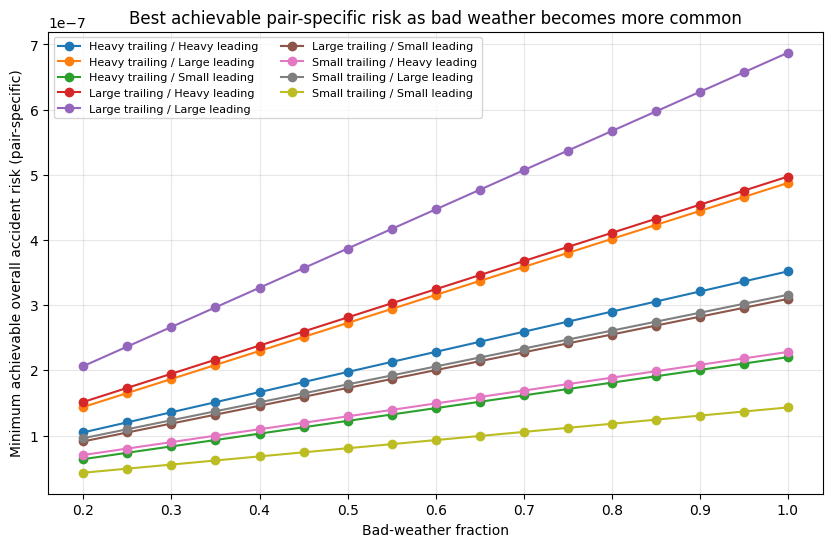

In [20]:
# Plot pair-specific minimum achievable risk as bad weather becomes more common
plt.figure(figsize=(10, 6))

for trailing_size in sensitivity_df["trailing_size"].unique():
    for leading_size in sensitivity_df["leading_size"].unique():
        subset = sensitivity_df[
            (sensitivity_df["trailing_size"] == trailing_size)
            & (sensitivity_df["leading_size"] == leading_size)
        ]
        plt.plot(
            subset["bad_weather_fraction"],
            subset["minimum_overall_accident_risk"],
            marker="o",
            label=f"{trailing_size} trailing / {leading_size} leading",
        )

plt.xlabel("Bad-weather fraction")
plt.ylabel("Minimum achievable overall accident risk (pair-specific)")
plt.title("Best achievable pair-specific risk as bad weather becomes more common")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.show()

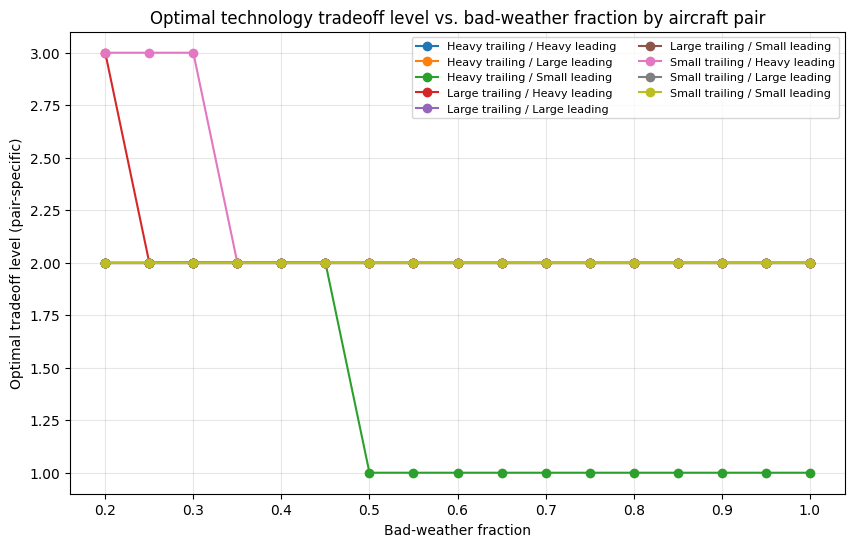

In [21]:
# Plot pair-specific optimal tradeoff level as bad weather becomes more common
plt.figure(figsize=(10, 6))

for trailing_size in sensitivity_df["trailing_size"].unique():
    for leading_size in sensitivity_df["leading_size"].unique():
        subset = sensitivity_df[
            (sensitivity_df["trailing_size"] == trailing_size)
            & (sensitivity_df["leading_size"] == leading_size)
        ]
        plt.plot(
            subset["bad_weather_fraction"],
            subset["optimal_tradeoff_level"],
            marker="o",
            label=f"{trailing_size} trailing / {leading_size} leading",
        )

plt.xlabel("Bad-weather fraction")
plt.ylabel("Optimal tradeoff level (pair-specific)")
plt.title("Optimal technology tradeoff level vs. bad-weather fraction by aircraft pair")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.show()


# 8. Final answer summary

The cell below prints a concise text summary that can be used as the backbone of your written discussion.


In [27]:
# ============================================================
# Human-readable summary (case-by-case reliability)
# ============================================================

required_objects = [
    "dangerous_wake_probability",
    "pair_occurence_probabilities",
    "pair_occurence_risk",
    "baseline_pair_df",
    "summary_good_bad",
    "results_80_20",
    "best_rows_80_20",
    "optimal_tradeoff_by_type",
    "scenario_summary_df",
    "sensitivity_df",
    "pair_summary_df",
    "aircraft_summary_df",
    "compute_mixed_weather_results",
    "tradeoff_table",
]

missing = [name for name in required_objects if name not in globals()]
if missing:
    print("Run the notebook in order before this final summary cell.")
    print("Missing objects:")
    for name in missing:
        print(f"- {name}")
else:
    print("CASE-BY-CASE WAKE-VORTEX INPUTS")
    print("P(D | trailing, leading):")
    print(dangerous_wake_probability)
    print()

    print("Pair occurrence probabilities P(trailing) * P(leading):")
    print(pair_occurence_probabilities)
    print()

    print("Weighted wake-danger contribution P(trailing) * P(leading) * P(D | trailing, leading):")
    print(pair_occurence_risk)
    print()

    baseline_table_for_print = (
        baseline_pair_df[
            [
                "weather",
                "trailing_size",
                "leading_size",
                "wake_vortex_risk_by_pair",
                "simultaneous_runway_occupancy_risk",
                "overall_accident_risk_by_pair",
            ]
        ]
        .sort_values(["weather", "trailing_size", "leading_size"])
        .reset_index(drop=True)
    )

    print("BASELINE COMPARISON (tradeoff level 1) - pair-specific overall risk")
    print("Each row shows weather + trailing aircraft + leading aircraft explicitly:")
    print(baseline_table_for_print.to_string(index=False))
    print()

    overall_risk_good = baseline_pair_df.loc[
        baseline_pair_df["weather"] == "good", "overall_accident_risk_by_pair"
    ].sum()
    overall_risk_bad = baseline_pair_df.loc[
        baseline_pair_df["weather"] == "bad", "overall_accident_risk_by_pair"
    ].sum()

    print(f"Overall accident risk when weather is good: {overall_risk_good}")
    print(f"Overall accident risk when weather is bad: {overall_risk_bad}")
    print()

    print("TECHNOLOGY OPTIMIZATION UNDER 80% GOOD / 20% BAD WEATHER")
    print("Best tradeoff level for each aircraft pair:")
    print(best_rows_80_20[[
        "trailing_size",
        "leading_size",
        "tradeoff_level",
        "overall_accident_risk_mixed",
        ]].to_string(index=False))
    print()

    risk_by_level_80_20 = (
        results_80_20.groupby("tradeoff_level", as_index=False)["overall_accident_risk_mixed"]
        .sum()
        .rename(columns={"overall_accident_risk_mixed": "total_overall_accident_risk_mixed"})
        .sort_values("tradeoff_level")
        .reset_index(drop=True)
    )
    best_level_row = risk_by_level_80_20.loc[
        risk_by_level_80_20["total_overall_accident_risk_mixed"].idxmin()
    ]

    print(
        "The level that the new technology should be utilized such that the overall accident risk "
        "due to insufficient in-trail separation is minimized: "
        f"{int(best_level_row['tradeoff_level'])}"
    )
    print(
        "Minimized overall accident risk under 80% good / 20% bad weather: "
        f"{best_level_row['total_overall_accident_risk_mixed']}"
    )
    print()

    print("AIRCRAFT-TYPE-SPECIFIC OPTIMIZATION (80% GOOD / 20% BAD)")
    print("Best tradeoff by aircraft type from exhaustive scenario search:")
    print(optimal_tradeoff_by_type.to_string(index=False))
    print()

    print("Top 10 (Heavy, Large, Small) level scenarios by mean pair risk:")
    print(scenario_summary_df.nsmallest(10, "mean_pair_risk").to_string(index=False))
    print()

    print("CLIMATE-CHANGE SENSITIVITY")
    pair_optima = sensitivity_df.groupby(["trailing_size", "leading_size"])["optimal_tradeoff_level"].unique()
    for pair, levels in pair_optima.items():
        trailing_size, leading_size = pair
        print(f"{trailing_size} trailing / {leading_size} leading -> optimal levels over weather sweep: {levels}")
    print()

    print("Climate sensitivity pair-level aggregate summary:")
    print(pair_summary_df.to_string(index=False))
    print()

    print("Climate sensitivity aircraft-level aggregate summary:")
    print(aircraft_summary_df.to_string(index=False))
    print()

    # Climate-impact interpretation based on how often optimal levels change over the weather sweep
    pair_level_change_count = (
        sensitivity_df.groupby(["trailing_size", "leading_size"])["optimal_tradeoff_level"]
        .nunique()
        .gt(1)
        .sum()
    )
    total_pairs = sensitivity_df.groupby(["trailing_size", "leading_size"]).ngroups

    all_levels_over_sweep = np.sort(sensitivity_df["optimal_tradeoff_level"].unique())

    print("How this climate change will affect the optimal tradeoff in the new technology:")
    if pair_level_change_count == 0:
        print(
            "Across the tested bad-weather range, the optimal tradeoff level is stable for all aircraft pairs "
            f"(levels observed: {all_levels_over_sweep.tolist()}). "
            "Climate change mainly increases risk magnitude rather than changing the selected level."
        )
    else:
        print(
            f"As bad-weather fraction increases, the optimal level changes for {int(pair_level_change_count)} "
            f"out of {int(total_pairs)} aircraft-pair cases (levels observed across sweep: {all_levels_over_sweep.tolist()}). "
            "So climate change affects both the risk magnitude and, for some pair cases, the recommended technology setting."
        )
    print()

    print("FUTURE-ROBUST TRADEOFF RECOMMENDATION")
    climate_rows = []
    for p_bad in sorted(sensitivity_df["bad_weather_fraction"].unique()):
        mixed_results = compute_mixed_weather_results(p_bad=float(p_bad))
        totals = (
            mixed_results.groupby("tradeoff_level", as_index=False)["overall_accident_risk_mixed"]
            .sum()
            .rename(columns={"overall_accident_risk_mixed": "total_overall_accident_risk"})
        )
        totals["bad_weather_fraction"] = float(p_bad)
        climate_rows.append(totals)

    climate_level_df = pd.concat(climate_rows, ignore_index=True)

    level_summary = (
        climate_level_df.groupby("tradeoff_level", as_index=False)
        .agg(
            mean_total_risk=("total_overall_accident_risk", "mean"),
            worst_total_risk=("total_overall_accident_risk", "max"),
        )
        .sort_values("tradeoff_level")
        .reset_index(drop=True)
    )

    best_fixed_level_row = level_summary.loc[level_summary["mean_total_risk"].idxmin()]
    best_fixed_level = int(best_fixed_level_row["tradeoff_level"])

    print("Single level to stick with in the future (minimizes average total risk over climate sweep):")
    print(f"Recommended fixed tradeoff level: {best_fixed_level}")
    print(
        "Average total accident risk at this fixed level over the climate sweep: "
        f"{best_fixed_level_row['mean_total_risk']}"
    )
    print(
        "Worst-case total accident risk at this fixed level over the climate sweep: "
        f"{best_fixed_level_row['worst_total_risk']}"
    )
    print()

    selected_level_path = (
        climate_level_df.loc[climate_level_df["tradeoff_level"] == best_fixed_level]
        [["bad_weather_fraction", "total_overall_accident_risk"]]
        .sort_values("bad_weather_fraction")
        .rename(columns={"total_overall_accident_risk": "overall_accident_risk_selected_level"})
        .reset_index(drop=True)
    )

    baseline_level_path = (
        climate_level_df.loc[climate_level_df["tradeoff_level"] == 1]
        [["bad_weather_fraction", "total_overall_accident_risk"]]
        .sort_values("bad_weather_fraction")
        .rename(columns={"total_overall_accident_risk": "overall_accident_risk_no_tradeoff_level_1"})
        .reset_index(drop=True)
    )

    comparison_df = selected_level_path.merge(
        baseline_level_path,
        on="bad_weather_fraction",
        how="inner",
    )
    comparison_df["absolute_risk_reduction"] = (
        comparison_df["overall_accident_risk_no_tradeoff_level_1"]
        - comparison_df["overall_accident_risk_selected_level"]
    )
    comparison_df["percent_risk_reduction"] = (
        100.0
        * comparison_df["absolute_risk_reduction"]
        / comparison_df["overall_accident_risk_no_tradeoff_level_1"]
    )

    print("Overall accident risk as climate changes at the selected fixed level:")
    print(selected_level_path.to_string(index=False))
    print()

    print("Benefit versus no-tradeoff baseline (level 1) across climate sweep:")
    print(comparison_df.to_string(index=False))
    print()

    all_points_better = bool((comparison_df["absolute_risk_reduction"] > 0).all())
    avg_percent_benefit = comparison_df["percent_risk_reduction"].mean()
    min_percent_benefit = comparison_df["percent_risk_reduction"].min()

    speed_decrease, reaction_increase = tradeoff_table[best_fixed_level]

    print("What this means:")
    if all_points_better:
        print(
            f"Using fixed level {best_fixed_level} is beneficial at every tested climate point "
            f"(average reduction {avg_percent_benefit:.2f}% and minimum reduction {min_percent_benefit:.2f}% "
            "versus no tradeoff)."
        )
    else:
        print(
            f"Using fixed level {best_fixed_level} is not better at every climate point, but it gives the best "
            "average performance across the full climate sweep."
        )

    print(
        "Why this happens: at this level, the model gets a meaningful decrease in pilot speed-adjustment failure "
        f"({speed_decrease}) while taking a smaller increase in go-around reaction-time failure ({reaction_increase}), "
        "so the net propagated accident risk is lower overall."
    )

CASE-BY-CASE WAKE-VORTEX INPUTS
P(D | trailing, leading):
       Heavy  Large  Small
Heavy   0.53   0.44   0.28
Large   0.74   0.61   0.41
Small   0.82   0.71   0.59

Pair occurrence probabilities P(trailing) * P(leading):
         Heavy    Large    Small
Heavy     0.11     0.15 6.93e-02
Large     0.15     0.21 9.66e-02
Small 6.93e-02 9.66e-02 4.41e-02

Weighted wake-danger contribution P(trailing) * P(leading) * P(D | trailing, leading):
         Heavy    Large    Small
Heavy 5.77e-02 6.68e-02 1.94e-02
Large     0.11     0.13 3.96e-02
Small 5.68e-02 6.86e-02 2.60e-02

BASELINE COMPARISON (tradeoff level 1) - pair-specific overall risk
Each row shows weather + trailing aircraft + leading aircraft explicitly:
weather trailing_size leading_size  wake_vortex_risk_by_pair  simultaneous_runway_occupancy_risk  overall_accident_risk_by_pair
    bad         Heavy        Heavy                  1.24e-08                            3.39e-07                       3.52e-07
    bad         Heavy     


# 9. Interpretation notes to mention in the submission

1. **Bad weather substantially increases accident risk.**  
   In this model, the increase is especially strong through the simultaneous-runway-occupancy pathway because bad weather greatly increases the probability of insufficient reaction time and also increases some other relevant event probabilities.

2. **The reliability methodology follows the lecture slides.**  
   The model is built using explicit **structure functions** with AND/OR combinations of elementary events, rather than by averaging event probabilities.

3. **The technology should be chosen using the final accident risk, not a local "benefit minus cost" score.**  
   The correct optimization criterion is the overall accident probability after all reliability logic is propagated through the system.

4. **For the climate-change part, a sensitivity analysis is the most defensible answer unless a specific future bad-weather percentage is provided.**

5. **Affect on Optimal Tradeoff in New Technology**
   As the fraction of bad weather increases, we can see that the optimal tradeoff level reamins level 2. The major difference we can see is that when the weather conditions become as bad as it can get at 100% of the time, the overall accident risk probability becomes 3.24e-6 which is where the baseline overall risk probability for bad weather was at without the new technology addition. Meaning the tradeoff the new technology affected really makes a difference in overall accident risk as having bad weather 100% of the time is not that probable.
